## **Weekly Budget Tracker Analysis**

In [2]:
import pandas as pd

## Loading Data

In [7]:
df = pd.read_csv("../data/budgetwise_synthetic_dirty.csv")

df.head()

,transaction_id,user_id,date,transaction_type,category,amount,payment_mode,location,notes
0,T03512,U039,December 22 2021,Expense,Rent,998,Cash,Pune,Paid electricity bill
1,T03261,U179,03/24/2022,Expense,Food,$143,Card,Delhi,Grocery shopping
2,T04316,U143,October 18 2022,Expense,Rent,149,Cash,Bengaluru,NaN
3,T05649,U079,12/12/2021,Expense,Rent,49,UPI,NaN,Paid electricity bill
4,T14750,U020,NaN,Income,Other Income,"83,802",Bank Transfer,Chennai,Gift via app


In [8]:
print(f"\nDataset shape: {df.shape}")


Dataset shape: (15836, 9)


In [ ]:
# unique value in each columns
df.value_counts()


transaction_id  user_id  date              transaction_type  category      amount  payment_mode   location   notes                 
T05932          U009     18-08-20          Expense           Utilities     1,446   UPI            Delhi      Netflix subscription      2
T09213          U157     17-05-20          Expense           Travel        6,822   Cash           Ahmedabad  Course fee                2
T13325          U033     2019-03-07        Expense           Food          118     Card           HYDERABAD  Course fee                2
T07059          U190     2020-11-20        Expense           Rent          3,472   UPI            Jaipur     Doctor visit via app      2
T09225          U027     2021-04-16        Income            Salary        54,869  Bank Transfer  Chennai    Gift                      2
                                                                                                                                      ..
T05191          U075     01/23/2021        Exp

## Data Cleaning

In [10]:
# Check for missing values 
df.isnull().sum()

transaction_id         0
user_id                0
date                 344
transaction_type       0
category             158
amount               178
payment_mode         503
location             722
notes               1534
dtype: int64

In [11]:
# Change the date and amount to usable datetime and number
df['date'] = pd.to_datetime(df["date"], format='mixed')
df['amount'] = pd.to_numeric(df['amount'], errors='coerce')

# Removing rows with Nan values across dataset
clean_df = df.dropna().reset_index(drop=True)

# Check duplicates
duplicates = clean_df.duplicated().sum()

print(f"\nDuplicate rows: {duplicates}")
if duplicates > 0:
    clean_df.drop_duplicates(inplace=True)
    print("Duplicates removed")



Duplicate rows: 349
Duplicates removed


## Data Analysis

In [12]:
# Basic statistic
print("\nDescriptive statistic")
clean_df.describe()


Descriptive statistic


,date,amount
count,6415,6415.000000
mean,2020-12-22 02:16:55.744349184,343.270928
min,2019-01-01 00:00:00,-970.000000
25%,2019-12-21 12:00:00,137.000000
50%,2020-12-14 00:00:00,277.000000
75%,2021-12-28 00:00:00,514.000000
max,2022-12-31 00:00:00,999.000000
std,NaN,261.774682


## Visualizations

In [13]:
import matplotlib.pyplot as plt

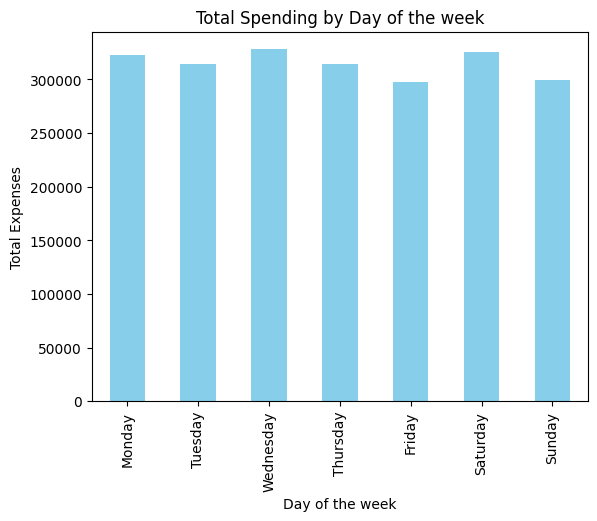

The day with the highest expenses is: Wednesday


In [14]:
# Visualization 1: Bar chart
clean_df['day_of_week'] = clean_df['date'].dt.day_name()
spendings_only = clean_df[clean_df['transaction_type'] == 'Expense']

days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

spending_by_the_day = spendings_only.groupby('day_of_week')['amount'].sum().reindex(days_order)

spending_by_the_day.plot(kind='bar', color='skyblue')
plt.title("Total Spending by Day of the week")
plt.xlabel('Day of the week')
plt.ylabel('Total Expenses')
plt.show()

print(f"The day with the highest expenses is: {spending_by_the_day.idxmax()}")


In [15]:
# Look at the unique values in the column
clean_df['category'].unique()

array(['Rent', 'Entertainment', 'Savings', 'Education', 'Food', 'Others',
       'Entertainmennt', 'Travel', 'Reent', 'Health', 'Utilities',
       'Traavel', 'Tavel', 'eRnt', 'Trave', 'Foo', 'Rnt', 'Fod', 'Foodd',
       'Rennt', 'Ret', 'Retn', 'aSvings', 'Utilitise', 'Travle', 'oFod',
       'Savingss', 'Otherrs', 'Foood', 'Entertainemnt', 'tOhers', 'ravel',
       'Trravel', 'Utiliies', 'Rnet', 'Saviings', 'ent', 'Savngs',
       'Svings', 'Utilitis', 'FFood', 'Trael', 'Utilitiees', 'Educationn',
       'Utillities', 'Otthers', 'Entertainmentt', 'Ren', 'Rentt',
       'Enttertainment', 'Entertaimnent', 'Utliities', 'rTavel',
       'Savinngs', 'Entertinment', 'Etertainment', 'ood', 'Other',
       'Utiltiies', 'Entretainment', 'Savigs', 'Entertanment',
       'Utiilties', 'Utiilities', 'Fodo', 'Trvel', 'Tarvel', 'RRent',
       'Trvael', 'Utilitiies', 'Saavings', 'EEntertainment', 'Travl',
       'Travell', 'Utilitiess', 'Entetainment', 'Utiliities', 'tilities',
       'Savins', 'Ed

In [16]:
# remove any spaces in the string and convert the string first letter to capital
clean_df['category'] = clean_df['category'].str.strip().str.title()

# correct mapping of the misspelt string to the rightly spelt ones
correction_map = {
    # Rent
    'Reent': 'Rent', 'Ernt': 'Rent', 'Rnt': 'Rent', 'Rennt': 'Rent', 'Ret': 'Rent', 'Retn': 'Rent', 
    'Rnet': 'Rent', 'Ren': 'Rent', 'Rentt': 'Rent', 'Rrent': 'Rent',
    
    # Entertainment
    'Entertainmennt': 'Entertainment', 'Entertainemnt': 'Entertainment', 'Ent': 'Entertainment', 
    'Entertainmentt': 'Entertainment', 'Enttertainment': 'Entertainment', 'Entertaimnent': 'Entertainment', 
    'Entertinment': 'Entertainment', 'Etertainment': 'Entertainment', 'Entretainment': 'Entertainment', 
    'Entertanment': 'Entertainment', 'Eentertainment': 'Entertainment', 'Entetainment': 'Entertainment', 
    'Netertainment': 'Entertainment', 'Enteratinment': 'Entertainment', 'Entertainmnet': 'Entertainment', 
    'Entertaniment': 'Entertainment', 'Etnertainment': 'Entertainment', 'Entertainmnt': 'Entertainment', 
    'Entertainmetn': 'Entertainment', 'Entertainent': 'Entertainment', 'Enertainment': 'Entertainment', 
    'Enteertainment': 'Entertainment', 'Enterttainment': 'Entertainment', 'Entertainnment': 'Entertainment', 
    'Entertainmet': 'Entertainment', 'Enntertainment': 'Entertainment',
    
    # Savings
    'Asvings': 'Savings', 'Savingss': 'Savings', 'Saviings': 'Savings', 'Savngs': 'Savings', 
    'Svings': 'Savings', 'Savinngs': 'Savings', 'Savigs': 'Savings', 'Saavings': 'Savings', 
    'Savins': 'Savings', 'Saving': 'Savings', 'Savnigs': 'Savings', 'Saings': 'Savings', 
    'Savinggs': 'Savings', 'Saivngs': 'Savings',
    
    # Education
    'Educationn': 'Education', 'Educcation': 'Education', 'Educatio': 'Education', 
    'Eduucation': 'Education', 'Educatino': 'Education', 'Edducation': 'Education', 'Educatioon': 'Education',
    
    # Food
    'Foo': 'Food', 'Fod': 'Food', 'Foodd': 'Food', 'Ofod': 'Food', 'Foood': 'Food', 
    'Ffood': 'Food', 'Ood': 'Food', 'Fodo': 'Food',
    
    # Others
    'Otherrs': 'Others', 'Tohers': 'Others', 'Otthers': 'Others', 'Other': 'Others', 'Thers': 'Others', 
    'Ohters': 'Others', 'Othhers': 'Others', 'Othes': 'Others', 'Oters': 'Others', 'Otehrs': 'Others', 
    'Othres': 'Others', 'Ohers': 'Others', 'Oothers': 'Others',
    
    # Travel
    'Traavel': 'Travel', 'Tavel': 'Travel', 'Trave': 'Travel', 'Travle': 'Travel', 'Ravel': 'Travel', 
    'Trravel': 'Travel', 'Trael': 'Travel', 'Rtavel': 'Travel', 'Trvel': 'Travel', 'Tarvel': 'Travel', 
    'Trvael': 'Travel', 'Travl': 'Travel', 'Travell': 'Travel', 'Traevl': 'Travel', 'Travvel': 'Travel', 
    'Ttravel': 'Travel', 'Traveel': 'Travel',
    
    # Health
    'Heaalth': 'Health', 'Helath': 'Health',
    
    # Utilities
    'Utilitise': 'Utilities', 'Utiliies': 'Utilities', 'Utilitis': 'Utilities', 'Utilitiees': 'Utilities', 
    'Utillities': 'Utilities', 'Utliities': 'Utilities', 'Utiltiies': 'Utilities', 'Utiilties': 'Utilities', 
    'Utiilities': 'Utilities', 'Utilitiies': 'Utilities', 'Utilitiess': 'Utilities', 'Tilities': 'Utilities', 
    'Utlities': 'Utilities', 'Uitlities': 'Utilities', 'Utilitie': 'Utilities', 'Utiities': 'Utilities', 
    'Utiliteis': 'Utilities', 'Utilites': 'Utilities', 'Uilities': 'Utilities', 'Uttilities': 'Utilities', 
    'Utilties': 'Utilities', 'Utiliities':'Utilities'
}

# Mapping them to the column
clean_df['category'] = clean_df['category'].replace(correction_map)

# The correct unique values in the column
print(clean_df['category'].unique())

['Rent' 'Entertainment' 'Savings' 'Education' 'Food' 'Others' 'Travel'
 'Health' 'Utilities']


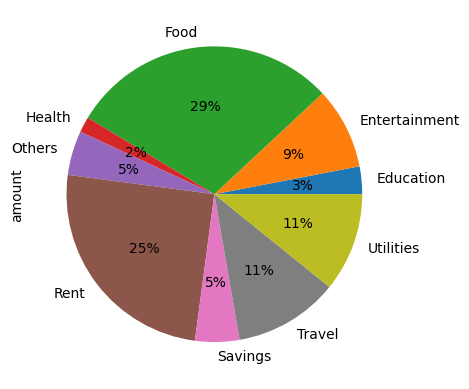

From the chart we would see that Food consumes most of our budget


In [17]:
# Visualization 2: Pie chart

clean_df.groupby('category')['amount'].sum().plot(kind='pie', y='amount', autopct='%1.0f%%')
plt.show()

print(f'From the chart we would see that {clean_df.groupby('category')['amount'].sum().idxmax()} consumes most of our budget')

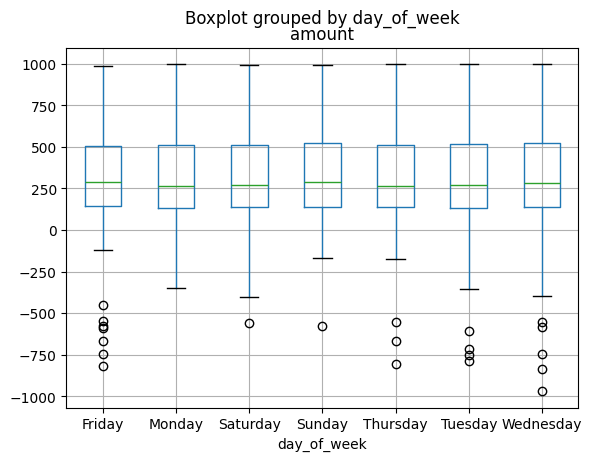

In [18]:
# Visualization 3: Boxplot

clean_df.boxplot(column='amount', by='day_of_week')
plt.show()

In [19]:
clean_df_copy = clean_df.copy()
print(f"I can save ${clean_df_copy[clean_df_copy['category'] == 'Entertainment']['amount'].sum() * 0.2} by cutting 20% from entertainment expenses")

I can save $39277.8 by cutting 20% from entertainment expenses


In [21]:
clean_df.to_csv("../data/Clean_budgetwise_data.csv", index=False)